In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")

OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

IMAGE_PATH = DATA_DIR / "xray.png"

## Load and Display

In [4]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Could not load image")

In [5]:
print("Shape:", img.shape)
print("Data type:", img.dtype)
print("Min:", img.min())
print("Max:", img.max())
print("Mean:", img.mean())

Shape: (256, 256)
Data type: uint8
Min: 0
Max: 255
Mean: 146.40380859375


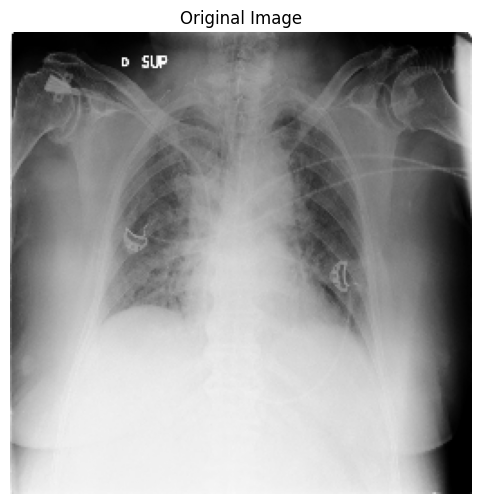

In [6]:
plt.figure(figsize=(6, 6))

plt.imshow(img, cmap="gray")

plt.title("Original Image")
plt.axis("off")

plt.show()

## Contrast Enhancement

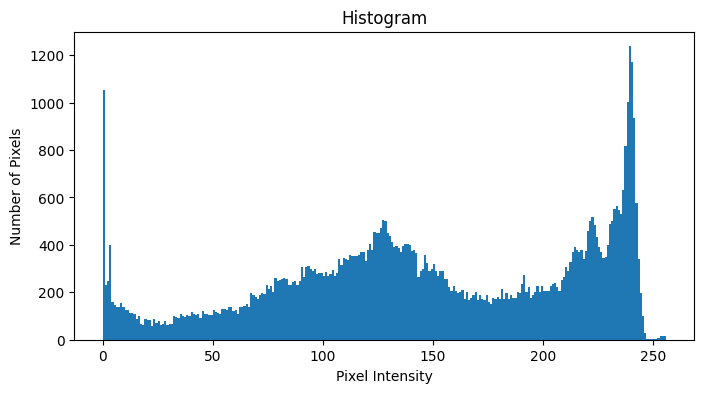

In [7]:
plt.figure(figsize=(8, 4))

plt.hist(img.ravel(), bins=256, range=[0, 256])

plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

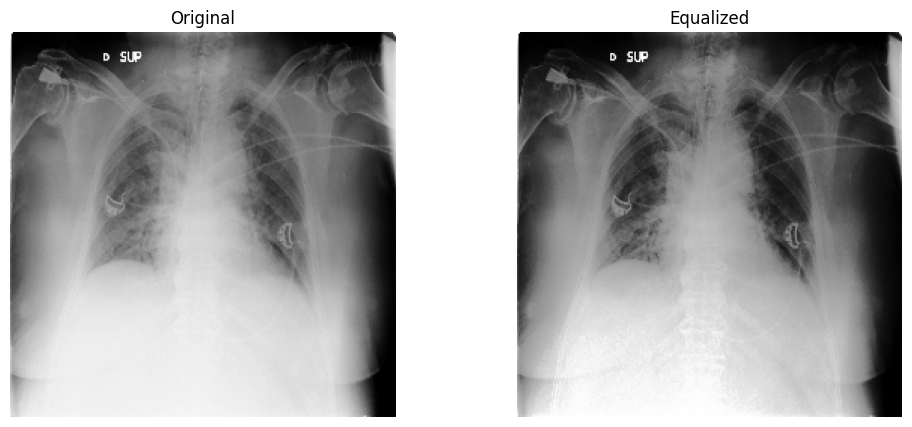

In [8]:
equalized = cv2.equalizeHist(img)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized")
plt.axis("off")

plt.show()

/tmp/ipykernel_5187/501201242.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,(0, 256))
/tmp/ipykernel_5187/501201242.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(),256,(0, 256))


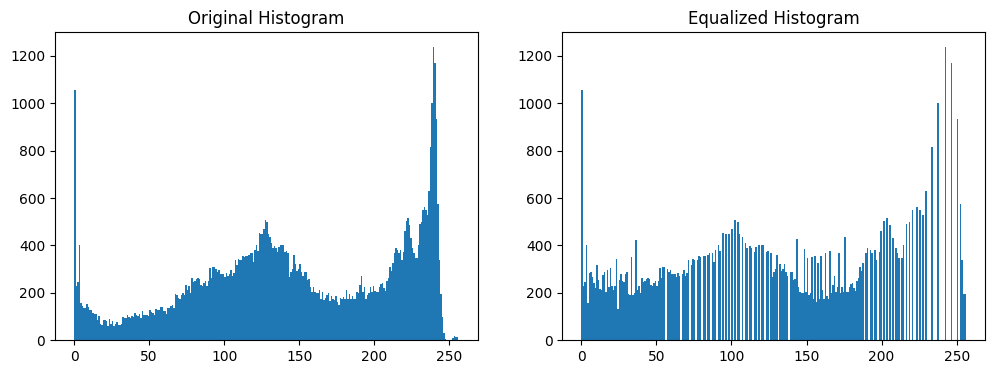

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(),256,(0, 256))
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(),256,(0, 256))
plt.title("Equalized Histogram")

plt.show()

## color mapping

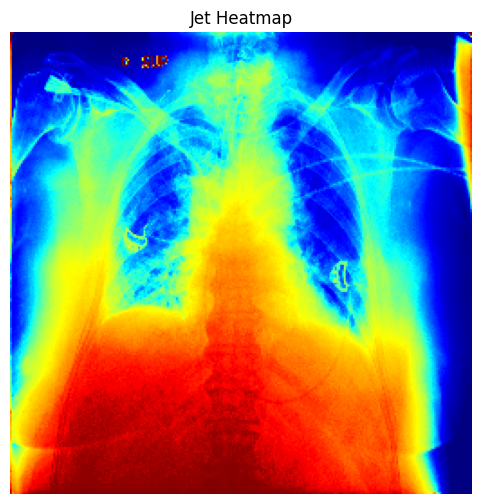

In [13]:
heatmap = cv2.applyColorMap(equalized,cv2.COLORMAP_JET)

heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))

plt.imshow(heatmap_rgb)
plt.title("Jet Heatmap")
plt.axis("off")

plt.show()

## Color Balance

In [15]:
def gray_world_balance(image):
    img_float = image.astype(np.float32)

    b, g, r = cv2.split(img_float)

    mean_b = np.mean(b)
    mean_g = np.mean(g)
    mean_r = np.mean(r)

    gray_mean = (mean_b + mean_g + mean_r) / 3.0

    b *= gray_mean / mean_b
    g *= gray_mean / mean_g
    r *= gray_mean / mean_r

    result = cv2.merge([b, g, r])

    return np.clip(result, 0,255).astype(np.uint8)

In [16]:
balanced = gray_world_balance(heatmap)

balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)

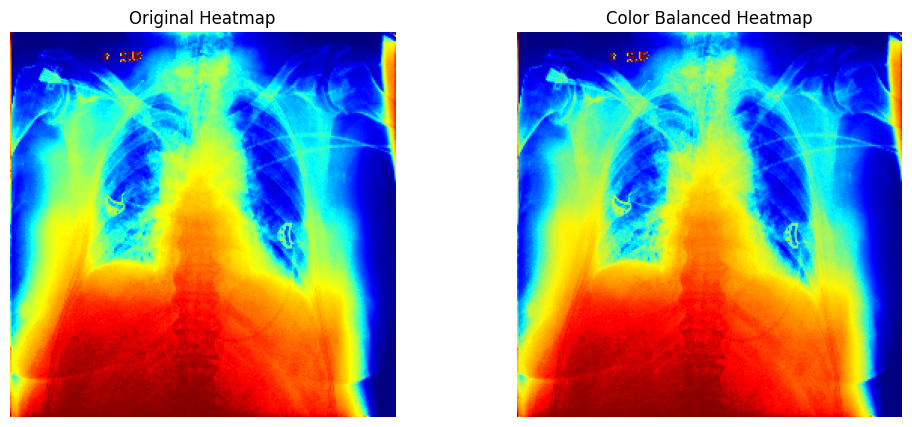

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(heatmap_rgb)
plt.title("Original Heatmap")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(balanced_rgb)
plt.title("Color Balanced Heatmap")
plt.axis("off")

plt.show()

## Thresholding

In [18]:
threshold_value = 200

_, binary_mask = cv2.threshold(equalized, threshold_value, 255, cv2.THRESH_BINARY)

filtered = cv2.bitwise_and(equalized, equalized, mask=binary_mask)

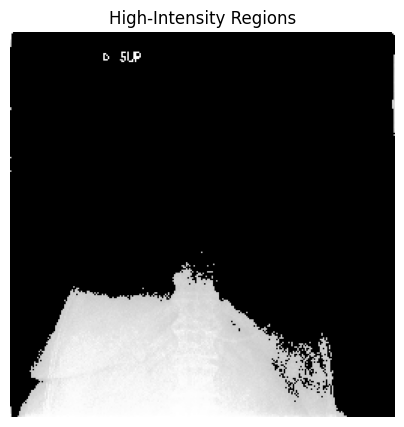

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.imshow(filtered, cmap="gray")
plt.title("High-Intensity Regions")
plt.axis("off")

plt.show()

## Log Function

In [21]:
def log_transform(image):
    img_float = image.astype(np.float32)

    c = 255 / np.log1p(np.max(img_float))

    result = c * np.log1p(img_float)

    return np.clip(result,0,255).astype(np.uint8)

In [22]:
log_image = log_transform(img)

Gamma Function

In [23]:
def gamma_transform(image, gamma=0.6):
    normalized = (image.astype(np.float32) / 255.0)

    corrected = np.power(normalized, gamma)

    corrected = corrected * 255

    return np.clip(corrected, 0, 255).astype(np.uint8)

In [24]:
gamma_image = gamma_transform(img, gamma=0.6)

Compare Log vs Gamma

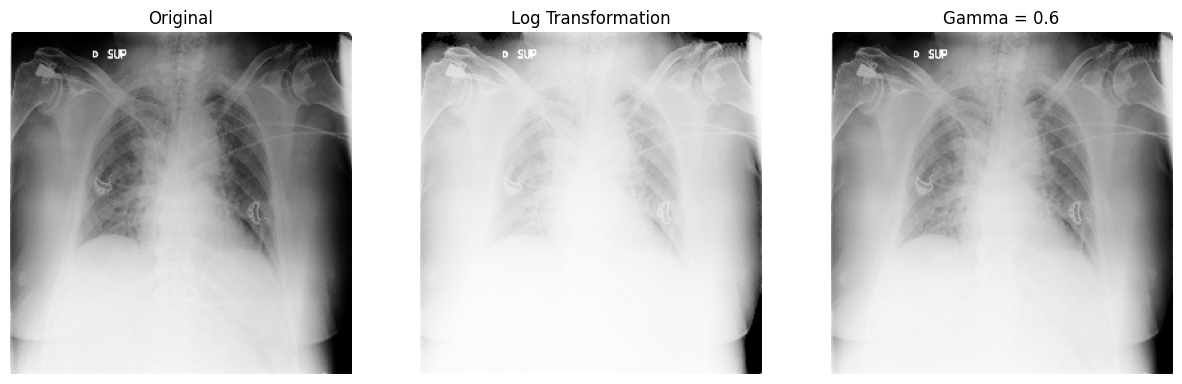

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(log_image, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gamma_image, cmap="gray")
plt.title("Gamma = 0.6")
plt.axis("off")

plt.show()

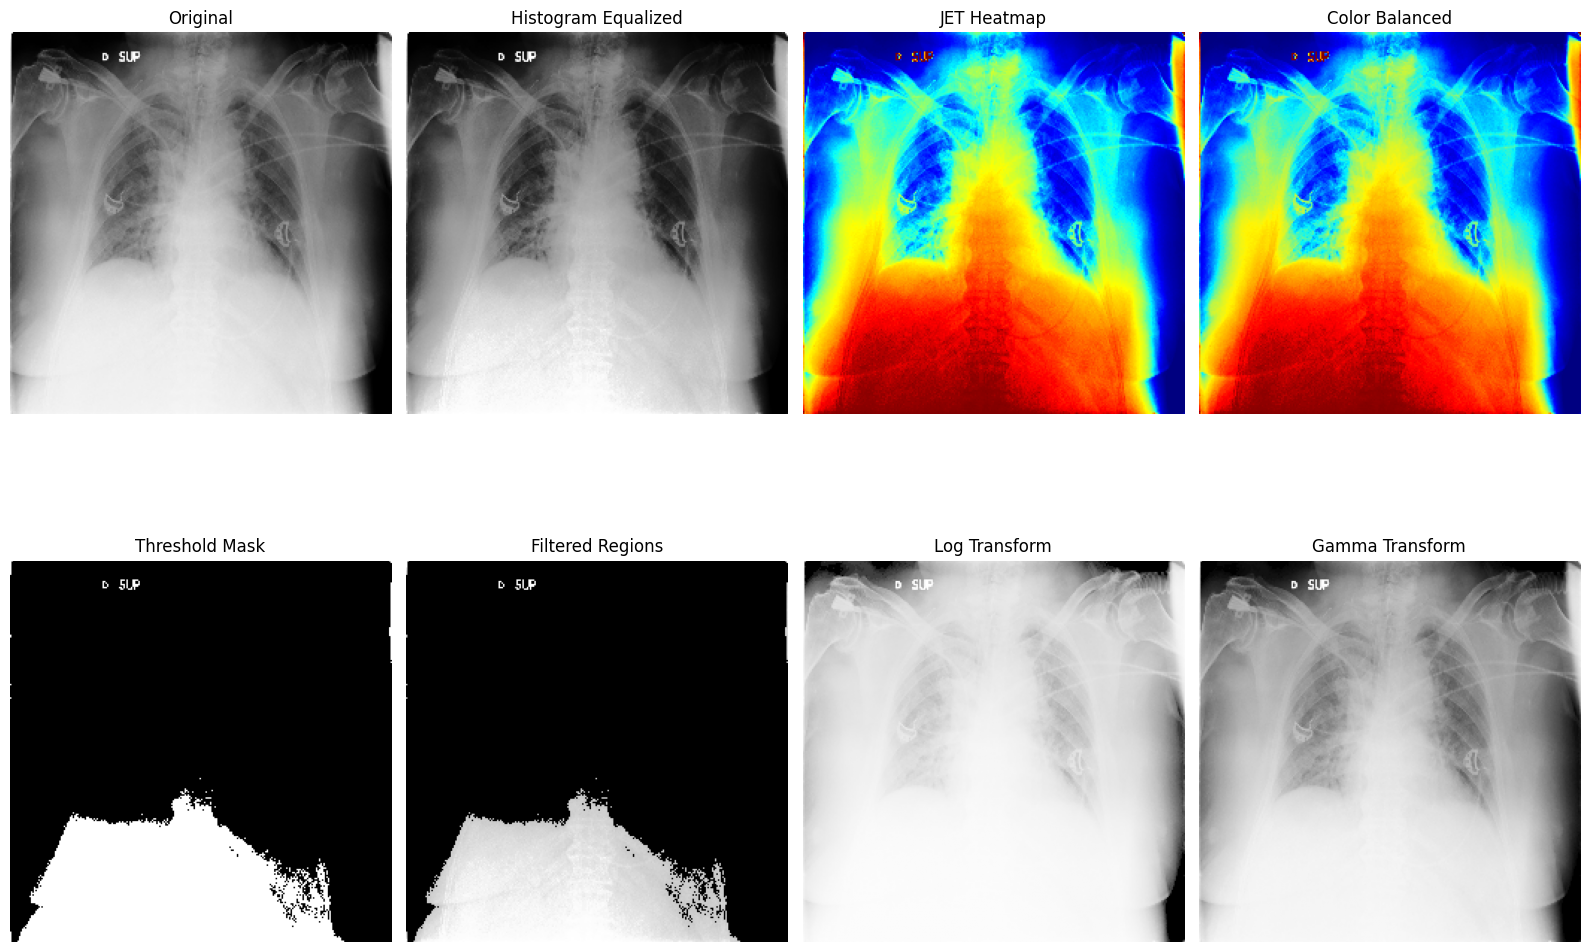

In [26]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(heatmap_rgb)
plt.title("JET Heatmap")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(balanced_rgb)
plt.title("Color Balanced")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(binary_mask, cmap="gray")
plt.title("Threshold Mask")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(filtered, cmap="gray")
plt.title("Filtered Regions")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(log_image, cmap="gray")
plt.title("Log Transform")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(gamma_image, cmap="gray")
plt.title("Gamma Transform")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
cv2.imwrite(
    str(OUTPUT_DIR / "equalized.png"),
    equalized
)

cv2.imwrite(
    str(OUTPUT_DIR / "heatmap.png"),
    heatmap
)

cv2.imwrite(
    str(OUTPUT_DIR / "balanced_heatmap.png"),
    balanced
)

cv2.imwrite(
    str(OUTPUT_DIR / "threshold_mask.png"),
    binary_mask
)

cv2.imwrite(
    str(OUTPUT_DIR / "log_transform.png"),
    log_image
)

cv2.imwrite(
    str(OUTPUT_DIR / "gamma_transform.png"),
    gamma_image
)

True